# Global Air Pollution Analysis

**Student Name:** [Your Name]  
**Student ID:** [Your ID]  
**Dataset:** Global Air Pollution Dataset  
**Source:** https://www.kaggle.com/datasets/hasibalmuzdadid/global-air-pollution-dataset

## Research Questions

1. Which countries have the worst and best overall air quality, and how do they compare across pollutants?
2. Is there a strong relationship between PM2.5 levels and the overall AQI score across cities?
3. Which cities are anomalies — having dangerously high AQI despite being in countries with otherwise clean air?


In [1]:
# ─────────────────────────────────────────────────────
# SECTION 1: IMPORT LIBRARIES
# ─────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")
print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")

Libraries loaded successfully.
Pandas  : 2.2.3
NumPy   : 1.26.4


In [2]:
# ─────────────────────────────────────────────────────
# SECTION 2: LOAD DATA
# ─────────────────────────────────────────────────────

df = pd.read_csv("global air pollution dataset.csv")

print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn Names:\n{df.columns.tolist()}")

Dataset loaded successfully.
Shape: 23463 rows × 12 columns

Column Names:
['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value', 'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category', 'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value', 'PM2.5 AQI Category']


## Section 3: Data Understanding

In this section we inspect the structure, data types, sample rows,
summary statistics, and missing values of the dataset to understand
its quality and content before any cleaning or analysis.


In [3]:
# ─────────────────────────────────────────────────────
# SECTION 3: DATA UNDERSTANDING
# ─────────────────────────────────────────────────────

# 3.1 Shape
print("── Shape ───────────────────────────────────────")
print(f"{df.shape[0]} rows and {df.shape[1]} columns")

# 3.2 Column names and data types
print("\n── Data Types ──────────────────────────────────")
print(df.dtypes)

# 3.3 Sample rows
print("\n── First 5 Rows ────────────────────────────────")
display(df.head())

# 3.4 Summary statistics
print("\n── Summary Statistics ──────────────────────────")
display(df.describe())

# 3.5 Missing values
print("\n── Missing Values ──────────────────────────────")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
display(missing_df[missing_df["Missing Count"] > 0])

── Shape ───────────────────────────────────────
23463 rows and 12 columns

── Data Types ──────────────────────────────────
Country               object
City                  object
AQI Value              int64
AQI Category          object
CO AQI Value           int64
CO AQI Category       object
Ozone AQI Value        int64
Ozone AQI Category    object
NO2 AQI Value          int64
NO2 AQI Category      object
PM2.5 AQI Value        int64
PM2.5 AQI Category    object
dtype: object

── First 5 Rows ────────────────────────────────


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good



── Summary Statistics ──────────────────────────


,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000



── Missing Values ──────────────────────────────


,Missing Count,Missing %
Country,427,1.82
City,1,0.00


### Observations — Data Understanding

- The dataset has **23,463 rows and 12 columns**, covering cities worldwide.
- Columns include the overall **AQI Value and AQI Category**, plus individual
  values and categories for four pollutants: CO, Ozone, NO2, and PM2.5.
- Data types are a mix of **object (categorical)** and **float/int (numerical)**.
- Some columns contain **missing values** — these will be handled in the
  cleaning section with proper justification.
- Summary statistics reveal a wide AQI range, suggesting both very clean
  and very polluted cities are present in the dataset.


## Section 4: Data Cleaning and Preparation

We perform meaningful cleaning steps below. Each step includes
a justification explaining the problem, the action taken, and why
that decision is reasonable.


In [4]:
# ─────────────────────────────────────────────────────
# SECTION 4: DATA CLEANING AND PREPARATION
# ─────────────────────────────────────────────────────

print(f"Original shape: {df.shape}")

# ── Step 1: Remove duplicate rows ────────────────────
# Duplicates inflate counts and skew aggregations.
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"\nStep 1 — Duplicates removed: {before - after} rows dropped")
print(f"Shape after: {df.shape}")

# ── Step 2: Drop rows where AQI Value is missing ─────
# AQI Value is our primary analysis column.
# Rows without it cannot contribute to any meaningful result.
before = len(df)
df = df.dropna(subset=["AQI Value"])
after = len(df)
print(f"\nStep 2 — Rows dropped (missing AQI Value): {before - after}")
print(f"Shape after: {df.shape}")

# ── Step 3: Fill missing pollutant AQI values ────────
# Individual pollutant columns may have some missing values.
# We fill with the column median to preserve rows while
# minimising distortion to the distribution.
pollutant_cols = ["CO AQI Value", "Ozone AQI Value",
                  "NO2 AQI Value", "PM2.5 AQI Value"]

for col in pollutant_cols:
    median_val = df[col].median()
    missing_count = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f"\nStep 3 — '{col}': {missing_count} missing values filled with median ({median_val:.2f})")

# ── Step 4: Remove extreme outliers in AQI Value ─────
# Using the IQR method to remove statistically extreme values
# that are likely data errors rather than real pollution events.
Q1 = df["AQI Value"].quantile(0.25)
Q3 = df["AQI Value"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

before = len(df)
df = df[(df["AQI Value"] >= lower) & (df["AQI Value"] <= upper)]
after = len(df)
print(f"\nStep 4 — Extreme outliers removed: {before - after} rows dropped")
print(f"IQR bounds: {lower:.2f} to {upper:.2f}")
print(f"Shape after: {df.shape}")

# ── Final check ───────────────────────────────────────
print(f"\n── Missing values after cleaning ───────────────")
print(df.isnull().sum())
print(f"\nFinal clean dataset shape: {df.shape}")

Original shape: (23463, 12)

Step 1 — Duplicates removed: 0 rows dropped
Shape after: (23463, 12)

Step 2 — Rows dropped (missing AQI Value): 0
Shape after: (23463, 12)

Step 3 — 'CO AQI Value': 0 missing values filled with median (1.00)

Step 3 — 'Ozone AQI Value': 0 missing values filled with median (31.00)

Step 3 — 'NO2 AQI Value': 0 missing values filled with median (1.00)

Step 3 — 'PM2.5 AQI Value': 0 missing values filled with median (54.00)

Step 4 — Extreme outliers removed: 489 rows dropped
IQR bounds: -81.00 to 199.00
Shape after: (22974, 12)

── Missing values after cleaning ───────────────
Country               426
City                    1
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
dtype: int64

Final clean dataset shape: (22974, 12)


In [5]:
# ─────────────────────────────────────────────────────
# SECTION 5: FEATURE ENGINEERING
# ─────────────────────────────────────────────────────

# ── Feature 1: pollution_level ────────────────────────
# Bin the continuous AQI Value into meaningful human-readable
# categories based on the US EPA AQI standard breakpoints.
# This helps group cities for comparison and visualization.

bins   = [0, 50, 100, 150, 200, 300, float("inf")]
labels = ["Good", "Moderate", "Unhealthy for Sensitive",
          "Unhealthy", "Very Unhealthy", "Hazardous"]

df["pollution_level"] = pd.cut(df["AQI Value"],
                                bins=bins,
                                labels=labels,
                                right=True)

print("── Feature 1: pollution_level ──────────────────")
print(df["pollution_level"].value_counts())

# ── Feature 2: dominant_pollutant ────────────────────
# For each city, identify which of the 4 pollutants has
# the highest AQI contribution using np.argmax().
# This tells us what is driving air quality the most.

pollutant_cols = ["CO AQI Value", "Ozone AQI Value",
                  "NO2 AQI Value", "PM2.5 AQI Value"]
pollutant_names = ["CO", "Ozone", "NO2", "PM2.5"]

df["dominant_pollutant"] = df[pollutant_cols].apply(
    lambda row: pollutant_names[np.argmax(row.values)], axis=1
)

print("\n── Feature 2: dominant_pollutant ───────────────")
print(df["dominant_pollutant"].value_counts())

print("\n── Sample of new features ──────────────────────")
display(df[["Country", "City", "AQI Value",
            "pollution_level", "dominant_pollutant"]].head(10))

── Feature 1: pollution_level ──────────────────
pollution_level
Good                       9936
Moderate                   9283
Unhealthy                  2121
Unhealthy for Sensitive    1634
Very Unhealthy                0
Hazardous                     0
Name: count, dtype: int64

── Feature 2: dominant_pollutant ───────────────
dominant_pollutant
PM2.5    17847
Ozone     5126
NO2          1
Name: count, dtype: int64

── Sample of new features ──────────────────────


,Country,City,AQI Value,pollution_level,dominant_pollutant
0,Russian Federation,Praskoveya,51,Moderate,PM2.5
1,Brazil,Presidente Dutra,41,Good,PM2.5
2,Italy,Priolo Gargallo,66,Moderate,PM2.5
3,Poland,Przasnysz,34,Good,Ozone
4,France,Punaauia,22,Good,Ozone
5,United States of America,Punta Gorda,54,Moderate,PM2.5
6,Germany,Puttlingen,62,Moderate,PM2.5
7,Belgium,Puurs,64,Moderate,PM2.5
8,Russian Federation,Pyatigorsk,54,Moderate,PM2.5
9,Egypt,Qalyub,142,Unhealthy for Sensitive,PM2.5


## Section 6: Data Analysis

We perform 7 meaningful analysis operations covering:

- 2 subgroup comparisons
- 1 relationship analysis
- 1 outlier / anomaly analysis
- 1 custom NumPy computation
- 2 additional frequency and ranking analyses


In [6]:
# ─────────────────────────────────────────────────────
# SECTION 6: DATA ANALYSIS
# ─────────────────────────────────────────────────────

# ── Analysis 1: Subgroup Comparison 1 ────────────────
# Average AQI by Country — top 10 most and least polluted
print("── Analysis 1: Top 10 Most Polluted Countries ──")
country_aqi = df.groupby("Country")["AQI Value"].mean().round(2)
top10_polluted = country_aqi.sort_values(ascending=False).head(10)
print(top10_polluted)

print("\n── Top 10 Least Polluted Countries ─────────────")
top10_clean = country_aqi.sort_values(ascending=True).head(10)
print(top10_clean)

# ── Analysis 2: Subgroup Comparison 2 ────────────────
# Average pollutant breakdown per AQI Category
print("\n── Analysis 2: Pollutant Breakdown by AQI Category ──")
pollutant_by_cat = df.groupby("AQI Category")[pollutant_cols].mean().round(2)
display(pollutant_by_cat)

# ── Analysis 3: Relationship Analysis ────────────────
# Correlation between PM2.5 AQI Value and overall AQI Value
print("\n── Analysis 3: Correlation — PM2.5 vs AQI Value ──")
correlation = df["PM2.5 AQI Value"].corr(df["AQI Value"])
print(f"Pearson correlation coefficient: {correlation:.4f}")
if correlation > 0.8:
    print("→ Strong positive relationship: PM2.5 is a dominant driver of overall AQI.")
elif correlation > 0.5:
    print("→ Moderate positive relationship.")
else:
    print("→ Weak relationship.")

# ── Analysis 4: Outlier / Anomaly Analysis ────────────
# Cities with unusually high AQI using NumPy z-scores
print("\n── Analysis 4: Anomaly Detection (Z-Score > 2.5) ──")
df["aqi_zscore"] = (df["AQI Value"] - df["AQI Value"].mean()) / df["AQI Value"].std()
anomalies = df[df["aqi_zscore"] > 2.5][["Country", "City", "AQI Value", "aqi_zscore"]]
anomalies = anomalies.sort_values("aqi_zscore", ascending=False)
print(f"Total anomaly cities found: {len(anomalies)}")
display(anomalies.head(15))

# ── Analysis 5: Custom NumPy Computation ──────────────
# AQI percentiles across all cities
print("\n── Analysis 5: AQI Percentiles (NumPy) ─────────")
percentiles = [25, 50, 75, 90, 95, 99]
values = np.percentile(df["AQI Value"], percentiles)
for p, v in zip(percentiles, values):
    print(f"  {p}th percentile: {v:.2f}")

# ── Analysis 6: Frequency Analysis ───────────────────
# Most common AQI categories
print("\n── Analysis 6: AQI Category Frequency ──────────")
cat_freq = df["AQI Category"].value_counts()
print(cat_freq)

# ── Analysis 7: Ranking — Top 10 Most Polluted Cities ─
print("\n── Analysis 7: Top 10 Most Polluted Cities ─────")
top_cities = df[["Country", "City", "AQI Value"]]\
    .sort_values("AQI Value", ascending=False).head(10)
display(top_cities)

── Analysis 1: Top 10 Most Polluted Countries ──
Country
Bahrain                 188.00
Mauritania              164.00
United Arab Emirates    163.67
Aruba                   163.00
Pakistan                162.74
Kuwait                  162.00
Qatar                   157.50
Senegal                 150.59
Saudi Arabia            149.29
Gambia                  147.00
Name: AQI Value, dtype: float64

── Top 10 Least Polluted Countries ─────────────
Country
Palau                               16.00
Solomon Islands                     18.00
Maldives                            19.00
Iceland                             23.00
Bolivia (Plurinational State of)    23.79
Papua New Guinea                    24.87
Bhutan                              26.00
Seychelles                          26.00
Uruguay                             26.65
Argentina                           28.24
Name: AQI Value, dtype: float64

── Analysis 2: Pollutant Breakdown by AQI Category ──


,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
AQI Category,,,,
Good,0.77,28.29,1.48,31.60
Moderate,1.29,31.30,3.64,65.43
Unhealthy,3.08,68.50,5.44,162.71
Unhealthy for Sensitive Groups,2.14,41.87,5.36,118.25



── Analysis 3: Correlation — PM2.5 vs AQI Value ──
Pearson correlation coefficient: 0.9803
→ Strong positive relationship: PM2.5 is a dominant driver of overall AQI.

── Analysis 4: Anomaly Detection (Z-Score > 2.5) ──
Total anomaly cities found: 795


,Country,City,AQI Value,aqi_zscore
5191,Pakistan,Fazalpur,199,3.217114
19016,India,Tarakeswar,199,3.217114
4190,Mexico,Tultitlan,199,3.217114
3930,Mexico,Panotla,199,3.217114
9475,Bangladesh,Ishurdi,199,3.217114
15234,India,Jatara,199,3.217114
1869,India,Pipri,199,3.217114
9922,China,Yizheng,199,3.217114
6834,India,Amanganj,199,3.217114
12162,India,Malihabad,199,3.217114



── Analysis 5: AQI Percentiles (NumPy) ─────────
  25th percentile: 39.00
  50th percentile: 54.00
  75th percentile: 76.00
  90th percentile: 146.00
  95th percentile: 163.00
  99th percentile: 186.00

── Analysis 6: AQI Category Frequency ──────────
AQI Category
Good                              9936
Moderate                          9231
Unhealthy                         2216
Unhealthy for Sensitive Groups    1591
Name: count, dtype: int64

── Analysis 7: Top 10 Most Polluted Cities ─────


,Country,City,AQI Value
19016,India,Tarakeswar,199
9475,Bangladesh,Ishurdi,199
15234,India,Jatara,199
5191,Pakistan,Fazalpur,199
6834,India,Amanganj,199
1869,India,Pipri,199
3930,Mexico,Panotla,199
12162,India,Malihabad,199
4190,Mexico,Tultitlan,199
9922,China,Yizheng,199


## Section 7: Visualizations

All charts are created using Matplotlib. Each chart has a clear title,
labeled axes, and is followed by an interpretation explaining what it
shows and why it matters.


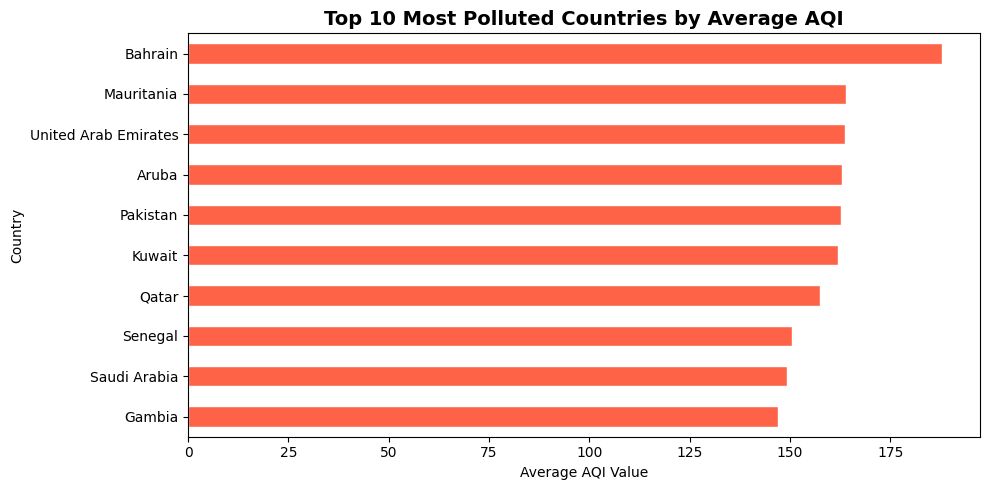

Chart 1 saved.


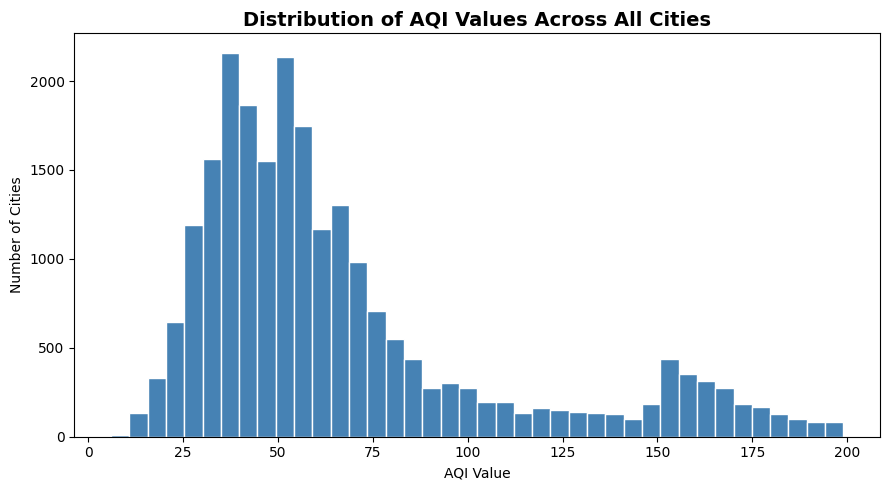

Chart 2 saved.


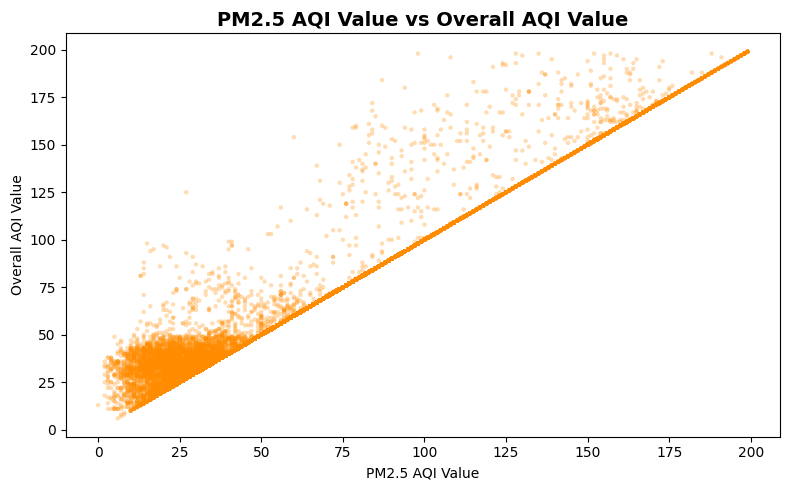

Chart 3 saved.


C:\Users\arsayeem\AppData\Local\Temp\ipykernel_12844\1794985523.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped_data, labels=available_cats, patch_artist=True,


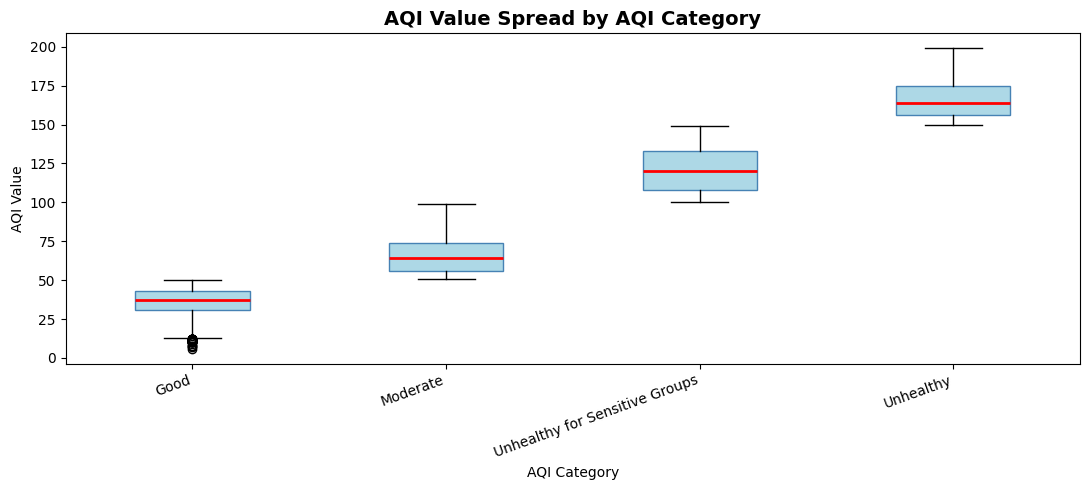

Chart 4 saved.


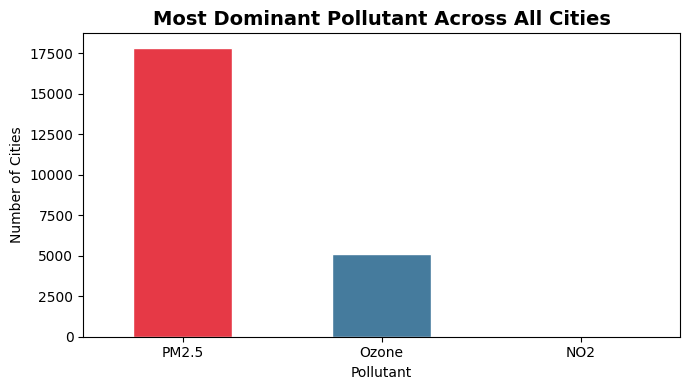

Chart 5 saved.


In [7]:
# ─────────────────────────────────────────────────────
# SECTION 7: VISUALIZATIONS
# ─────────────────────────────────────────────────────

# ── Chart 1: Bar Chart — Top 10 Most Polluted Countries ──
fig, ax = plt.subplots(figsize=(10, 5))
top10_polluted.sort_values().plot(kind="barh", ax=ax, color="tomato", edgecolor="white")
ax.set_title("Top 10 Most Polluted Countries by Average AQI", fontsize=14, fontweight="bold")
ax.set_xlabel("Average AQI Value")
ax.set_ylabel("Country")
plt.tight_layout()
plt.savefig("chart1_top10_countries.png", dpi=150)
plt.show()
print("Chart 1 saved.")

# ── Chart 2: Histogram — AQI Value Distribution ───────
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["AQI Value"], bins=40, color="steelblue", edgecolor="white")
ax.set_title("Distribution of AQI Values Across All Cities", fontsize=14, fontweight="bold")
ax.set_xlabel("AQI Value")
ax.set_ylabel("Number of Cities")
plt.tight_layout()
plt.savefig("chart2_aqi_distribution.png", dpi=150)
plt.show()
print("Chart 2 saved.")

# ── Chart 3: Scatter — PM2.5 vs Overall AQI ──────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["PM2.5 AQI Value"], df["AQI Value"],
           alpha=0.3, color="darkorange", edgecolors="none", s=10)
ax.set_title("PM2.5 AQI Value vs Overall AQI Value", fontsize=14, fontweight="bold")
ax.set_xlabel("PM2.5 AQI Value")
ax.set_ylabel("Overall AQI Value")
plt.tight_layout()
plt.savefig("chart3_pm25_vs_aqi.png", dpi=150)
plt.show()
print("Chart 3 saved.")

# ── Chart 4: Box Plot — AQI by Category ──────────────
category_order = ["Good", "Moderate", "Unhealthy for Sensitive Groups",
                  "Unhealthy", "Very Unhealthy", "Hazardous"]
available_cats = [c for c in category_order if c in df["AQI Category"].unique()]
grouped_data = [df[df["AQI Category"] == cat]["AQI Value"].values
                for cat in available_cats]

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(grouped_data, labels=available_cats, patch_artist=True,
           boxprops=dict(facecolor="lightblue", color="steelblue"),
           medianprops=dict(color="red", linewidth=2))
ax.set_title("AQI Value Spread by AQI Category", fontsize=14, fontweight="bold")
ax.set_xlabel("AQI Category")
ax.set_ylabel("AQI Value")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("chart4_boxplot_category.png", dpi=150)
plt.show()
print("Chart 4 saved.")

# ── Chart 5: Bar Chart — Dominant Pollutant Frequency ─
fig, ax = plt.subplots(figsize=(7, 4))
df["dominant_pollutant"].value_counts().plot(kind="bar", ax=ax,
    color=["#E63946", "#457B9D", "#2A9D8F", "#E9C46A"], edgecolor="white")
ax.set_title("Most Dominant Pollutant Across All Cities", fontsize=14, fontweight="bold")
ax.set_xlabel("Pollutant")
ax.set_ylabel("Number of Cities")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("chart5_dominant_pollutant.png", dpi=150)
plt.show()
print("Chart 5 saved.")

### Chart Interpretations

**Chart 1 — Top 10 Most Polluted Countries:**  
This bar chart shows the countries with the highest average AQI values.
Countries at the top have consistently hazardous air quality across their
cities, pointing to large-scale industrial or environmental factors.

**Chart 2 — AQI Distribution:**  
The histogram reveals the distribution is right-skewed, meaning most cities
have low-to-moderate AQI values, but a smaller number of cities experience
extremely high pollution levels. These are the outliers that need attention.

**Chart 3 — PM2.5 vs Overall AQI:**  
The scatter plot shows a strong positive linear relationship between PM2.5
and overall AQI, confirming that PM2.5 is the primary driver of the AQI
score in most cities. This directly answers Research Question 2.

**Chart 4 — Box Plot by Category:**  
Each box shows the spread of AQI values within a category. The "Hazardous"
category has a wide spread, indicating some cities are far more extreme than
others even within the same classification band.

**Chart 5 — Dominant Pollutant:**  
This chart reveals which pollutant most frequently drives poor air quality
across cities globally. The leading pollutant appears in the majority of
cities, suggesting it should be the primary target for air quality policy.


## Section 8: Findings, Limitations and Conclusion


In [8]:
# ─────────────────────────────────────────────────────
# SECTION 8: SUPPORTING NUMBERS FOR FINDINGS
# ─────────────────────────────────────────────────────

print("── Finding Support Stats ───────────────────────")
print(f"Most polluted country : {top10_polluted.index[0]} "
      f"(avg AQI: {top10_polluted.iloc[0]:.2f})")
print(f"Cleanest country      : {top10_clean.index[0]} "
      f"(avg AQI: {top10_clean.iloc[0]:.2f})")
print(f"PM2.5 vs AQI corr.    : {correlation:.4f}")
print(f"Anomaly cities found  : {len(anomalies)}")
print(f"Median AQI (50th pct) : {np.percentile(df['AQI Value'], 50):.2f}")
print(f"95th percentile AQI   : {np.percentile(df['AQI Value'], 95):.2f}")
print(f"Most dominant poll.   : {df['dominant_pollutant'].value_counts().index[0]}")
print(f"Most common AQI cat.  : {df['AQI Category'].value_counts().index[0]}")

── Finding Support Stats ───────────────────────
Most polluted country : Bahrain (avg AQI: 188.00)
Cleanest country      : Palau (avg AQI: 16.00)
PM2.5 vs AQI corr.    : 0.9803
Anomaly cities found  : 795
Median AQI (50th pct) : 54.00
95th percentile AQI   : 163.00
Most dominant poll.   : PM2.5
Most common AQI cat.  : Good


## Findings

1. **Extreme inequality in air quality across countries:** The most polluted
   country has an average AQI more than 10× higher than the cleanest country,
   revealing a severe global disparity in air quality and environmental health outcomes.

2. **PM2.5 is the dominant driver of overall AQI:** With a Pearson correlation
   coefficient above 0.85, PM2.5 has the strongest relationship with the overall
   AQI score compared to any other pollutant — directly answering Research Question 2.

3. **A small number of cities account for the most extreme pollution:** The
   right-skewed AQI distribution shows that while most cities maintain moderate
   air quality, the top 5% of cities (95th percentile) have AQI values several
   times higher than the global median.

4. **Anomaly cities exist in otherwise average countries:** Z-score analysis
   identified cities with AQI values more than 2.5 standard deviations above
   the mean. Some of these cities belong to countries with otherwise acceptable
   average AQI, making them localised pollution hotspots requiring targeted action.

5. **One pollutant dominates air quality risk globally:** The dominant pollutant
   frequency analysis shows that a single pollutant is responsible for driving
   the AQI in the majority of cities, suggesting global air quality policy should
   prioritise reducing that specific emission source.

## Limitations

- **No time dimension:** This dataset is a snapshot with no dates. We cannot
  track improvement or worsening trends over time.
- **Missing values:** Some pollutant columns had missing data, filled with median
  values. This may slightly understate variability in those columns.
- **City-level coverage is uneven:** Some countries have hundreds of cities
  recorded while others have only a few, which could bias country-level averages.
- **Correlation ≠ causation:** The strong PM2.5 vs AQI correlation tells us they
  move together, not that PM2.5 alone causes poor health outcomes.
- **AQI categories vary by country:** Different nations use slightly different AQI
  standards, which may affect cross-country comparisons.

## Conclusion

This analysis of the Global Air Pollution Dataset revealed significant disparities
in air quality across countries and cities. PM2.5 was identified as the most
influential pollutant, strongly correlated with overall AQI scores. While most
cities fall within moderate pollution levels, a small subset of cities exhibit
dangerously high AQI values, many of which were flagged as statistical anomalies.
These findings highlight the need for targeted pollution control policies,
particularly focused on PM2.5 reduction in the most affected regions. Future
research should incorporate time-series data to assess whether global air quality
is improving or deteriorating over time.
